In [6]:
pip install tensorflow numpy matplotlib seaborn

Dataset ready — 10000 samples
Example  input : [9 3 3 5 9]
Example target : [9 5 3 3 9]
Epoch   5/40  —  loss: 0.0132
Epoch  10/40  —  loss: 0.0034
Epoch  15/40  —  loss: 0.0016
Epoch  20/40  —  loss: 0.0009
Epoch  25/40  —  loss: 0.0006
Epoch  30/40  —  loss: 0.0004
Epoch  35/40  —  loss: 0.0003
Epoch  40/40  —  loss: 0.0002

Token accuracy on 1000 samples: 1.000


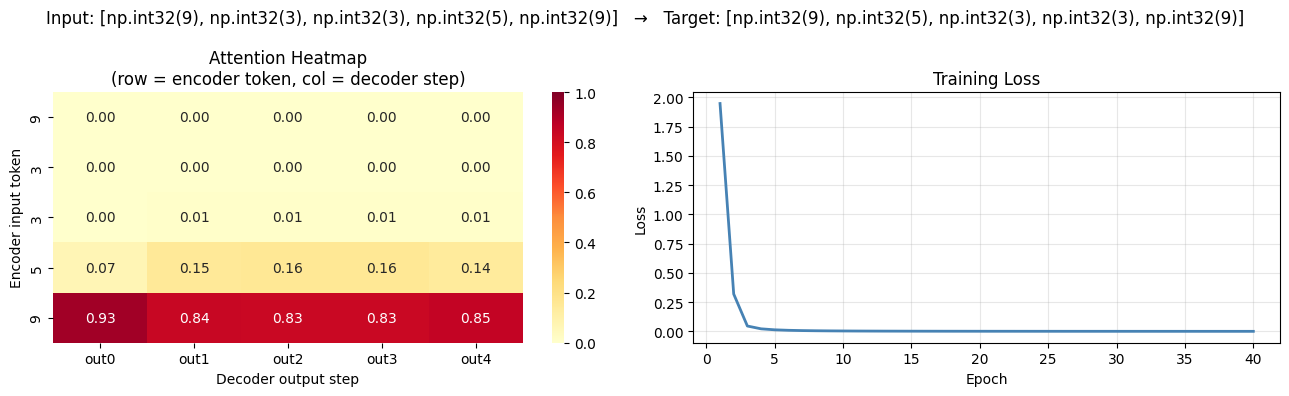


Heatmap saved as lab6_attention_heatmap.png
Done!


In [7]:
# ─────────────────────────────────────────────────────────────────
#  Lab 6 : Seq2Seq with Bahdanau Attention + Heatmap Visualization
# ─────────────────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ───────────────────────────────────────────────
VOCAB     = 11          # tokens 1-10  (0 = padding, unused here)
SEQ_LEN   = 5
EMBED_DIM = 16
UNITS     = 32
BATCH     = 128
EPOCHS    = 40


# ════════════════════════════════════════════════════════════════
#  1.  Bahdanau Attention Layer
# ════════════════════════════════════════════════════════════════
class BahdanauAttention(layers.Layer):
    """
    Additive (Bahdanau) attention.
      query  : decoder hidden state  — shape (batch, units)
      values : all encoder outputs   — shape (batch, T_enc, units)
    Returns:
      context : weighted sum of values — (batch, units)
      weights : attention distribution — (batch, T_enc, 1)
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)   # projects encoder outputs
        self.W2 = layers.Dense(units)   # projects decoder query
        self.V  = layers.Dense(1)       # scalar score per encoder step

    def call(self, query, values):
        # Expand query to broadcast over encoder time steps
        query_exp = tf.expand_dims(query, 1)               # (batch,1,units)

        # Alignment score  e_t = V · tanh(W1·h_enc + W2·s_dec)
        score = self.V(tf.nn.tanh(self.W1(values)
                                  + self.W2(query_exp)))   # (batch,T_enc,1)

        # Softmax → attention weights (sum to 1 over encoder positions)
        weights = tf.nn.softmax(score, axis=1)             # (batch,T_enc,1)

        # Context vector = weighted sum of encoder hidden states
        context = tf.reduce_sum(weights * values, axis=1)  # (batch,units)

        return context, weights   # return weights for heatmap


# ════════════════════════════════════════════════════════════════
#  2.  Seq2Seq Model  (subclassed — avoids KerasTensor errors)
# ════════════════════════════════════════════════════════════════
class Seq2SeqAttention(Model):
    def __init__(self, vocab, embed_dim, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

        # Shared embedding for encoder & decoder
        self.embedding = layers.Embedding(vocab, embed_dim)

        # Encoder : returns all hidden states + final state
        self.enc_lstm  = layers.LSTM(units,
                                     return_sequences=True,
                                     return_state=True)

        # Attention mechanism
        self.attention = BahdanauAttention(units)

        # Decoder : LSTMCell steps one token at a time
        self.dec_cell  = layers.LSTMCell(units)

        # Final projection to vocabulary
        self.out_dense = layers.Dense(vocab, activation='softmax')

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs   # both: (batch, SEQ_LEN)

        # ── Encoder ──────────────────────────────────────────────
        enc_emb = self.embedding(enc_input)              # (batch,T,embed)
        enc_out, enc_h, enc_c = self.enc_lstm(enc_emb)
        #   enc_out : (batch, T_enc, units) — all hidden states
        #   enc_h/c : (batch, units)        — final states

        # ── Decoder  (step through dec_input) ────────────────────
        dec_emb    = self.embedding(dec_input)           # (batch,T,embed)
        state_h    = enc_h
        state_c    = enc_c
        outputs    = []
        attn_list  = []                                  # collect for heatmap

        for t in range(SEQ_LEN):
            step = dec_emb[:, t, :]                      # (batch, embed)

            # Attention: where to look in encoder outputs
            context, w = self.attention(state_h, enc_out)
            attn_list.append(w)                          # (batch, T_enc, 1)

            # Merge attended context with current token embedding
            cell_in = tf.concat([step, context], axis=-1) # (batch, embed+units)

            # One LSTMCell step
            _, [state_h, state_c] = self.dec_cell(
                cell_in, states=[state_h, state_c])

            # Project to vocab distribution
            outputs.append(self.out_dense(state_h))      # (batch, vocab)

        # ── Stack outputs ─────────────────────────────────────────
        outputs  = tf.stack(outputs,  axis=1)            # (batch, T_dec, vocab)
        # attn_list: T_dec × (batch, T_enc, 1)
        # → concat along last axis → (batch, T_enc, T_dec)
        attn_map = tf.concat(attn_list, axis=2)

        return outputs, attn_map


# ════════════════════════════════════════════════════════════════
#  3.  Synthetic Dataset  — reverse a 5-integer sequence
#      e.g.  [3, 7, 1, 9, 4]  →  [4, 9, 1, 7, 3]
# ════════════════════════════════════════════════════════════════
def make_dataset(n=10000):
    X = np.random.randint(1, VOCAB, (n, SEQ_LEN)).astype(np.int32)
    Y = X[:, ::-1].astype(np.int32)
    return X, Y

X_train, Y_train = make_dataset()
print(f"Dataset ready — {len(X_train)} samples")
print(f"Example  input : {X_train[0]}")
print(f"Example target : {Y_train[0]}")


# ════════════════════════════════════════════════════════════════
#  4.  Custom Training Loop
#      (model returns a tuple so .fit() can't be used directly)
# ════════════════════════════════════════════════════════════════
model     = Seq2SeqAttention(VOCAB, EMBED_DIM, UNITS)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        y_pred, _ = model((x, y), training=True)       # ignore attn during train
        loss = loss_fn(y, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

n_batches = len(X_train) // BATCH
loss_history = []

for epoch in range(EPOCHS):
    idx  = np.random.permutation(len(X_train))
    ep_loss = 0.0
    for i in range(0, len(X_train), BATCH):
        b   = idx[i:i+BATCH]
        ep_loss += train_step(X_train[b], Y_train[b]).numpy()
    avg = ep_loss / n_batches
    loss_history.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  —  loss: {avg:.4f}")


# ════════════════════════════════════════════════════════════════
#  5.  Evaluate  (token-level accuracy)
# ════════════════════════════════════════════════════════════════
preds, _ = model((X_train[:1000], Y_train[:1000]), training=False)
pred_ids  = tf.argmax(preds, axis=-1).numpy()
acc = np.mean(pred_ids == Y_train[:1000])
print(f"\nToken accuracy on 1000 samples: {acc:.3f}")


# ════════════════════════════════════════════════════════════════
#  6.  Visualize Attention Heatmap
# ════════════════════════════════════════════════════════════════
sample_x = X_train[:1]    # shape (1, 5)
sample_y = Y_train[:1]    # shape (1, 5)

_, attn = model((sample_x, sample_y), training=False)
# attn : (1, T_enc=5, T_dec=5)
attn_np = attn[0].numpy()     # (5, 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── (a) Attention heatmap ─────────────────────────────────────
sns.heatmap(
    attn_np,
    ax=axes[0],
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    xticklabels=[f"out{i}" for i in range(SEQ_LEN)],
    yticklabels=[str(t) for t in sample_x[0]]
)
axes[0].set_title("Attention Heatmap\n(row = encoder token, col = decoder step)")
axes[0].set_xlabel("Decoder output step")
axes[0].set_ylabel("Encoder input token")

# ── (b) Training loss curve ───────────────────────────────────
axes[1].plot(range(1, EPOCHS+1), loss_history, color='steelblue', linewidth=2)
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"Input: {list(sample_x[0])}   →   Target: {list(sample_y[0])}",
    fontsize=12
)
plt.tight_layout()
plt.savefig("lab6_attention_heatmap.png", dpi=150)
plt.show()

print("\nHeatmap saved as lab6_attention_heatmap.png")
print("Done!")